# Кластеризация

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm import tqdm
import os
import sys

sys.path.append('..')
from utils import dunn_index, compute_gap_statistic, get_cluster_report, get_centroid_examples

RANDOM_STATE = 42

Загрузка данных

In [2]:
df = pd.read_csv(
    "../data/split/02_text_for_vectorization.csv"
)

X_e5 = np.load(
    "../data/embeddings/e5.npy"
)

# E5 embeddings

Нормализация

In [3]:
X_e5_norm = normalize(X_e5)

Подбор PCA

In [12]:
pca_dims = [50, 100, 200, None]

k_range = range(5, 21)

results_e5 = []

for n_comp in pca_dims:

    print("=" * 80)
    print(f"PCA = {n_comp}")
    print("=" * 80)

    if n_comp is not None:

        pca = PCA(
            n_components=n_comp,
            random_state=RANDOM_STATE
        )

        X_current = pca.fit_transform(
            X_e5_norm
        )

        print(
            f"After PCA: "
            f"{X_current.shape}"
        )

    else:

        X_current = X_e5_norm

        print(
            "Without PCA"
        )

    for k in tqdm(
        k_range,
        desc=f"KMeans PCA={n_comp}"
    ):

        km = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init='auto'
        )

        labels = km.fit_predict(
            X_current
        )

        sil = silhouette_score(
            X_current,
            labels
        )

        ch = calinski_harabasz_score(
            X_current,
            labels
        )

        db = davies_bouldin_score(
            X_current,
            labels
        )

        dunn = dunn_index(
            X_current,
            labels
        )

        gap = compute_gap_statistic(
            X_current,
            k
        )

        results_e5.append({

            'pca_dim': n_comp,

            'k': k,

            'silhouette': sil,

            'calinski_harabasz': ch,

            'davies_bouldin': db,

            'dunn': dunn,

            'gap': gap,

            'wss': km.inertia_
        })

df_e5_metrics = pd.DataFrame(
    results_e5
)

os.makedirs(
    "../data/results/metrics/e5",
    exist_ok=True
)

df_e5_metrics.to_csv(

    "../data/results/metrics/e5/"
    "e5_kmeans_metrics.csv",

    index=False
)

df_e5_metrics.head()

PCA = 50
After PCA: (10467, 50)


KMeans PCA=50: 100%|██████████| 16/16 [01:01<00:00,  3.83s/it]


PCA = 100
After PCA: (10467, 100)


KMeans PCA=100: 100%|██████████| 16/16 [01:24<00:00,  5.30s/it]


PCA = 200
After PCA: (10467, 200)


KMeans PCA=200: 100%|██████████| 16/16 [02:16<00:00,  8.55s/it]


PCA = None
Without PCA


KMeans PCA=None: 100%|██████████| 16/16 [09:20<00:00, 35.06s/it]


,pca_dim,k,silhouette,calinski_harabasz,davies_bouldin,dunn,gap,wss
0,50.0,5,0.070158,652.957493,3.125270,0.103017,4.319922,557.162109
1,50.0,6,0.073916,595.518168,2.941526,0.110622,4.341431,541.987793
2,50.0,7,0.069486,546.923863,3.088489,0.125194,4.359452,529.987854
3,50.0,8,0.065964,503.903803,2.986763,0.053878,4.372333,520.662292
4,50.0,9,0.068096,476.478675,2.918849,0.114195,4.387988,510.269714


Визуализируем метрики

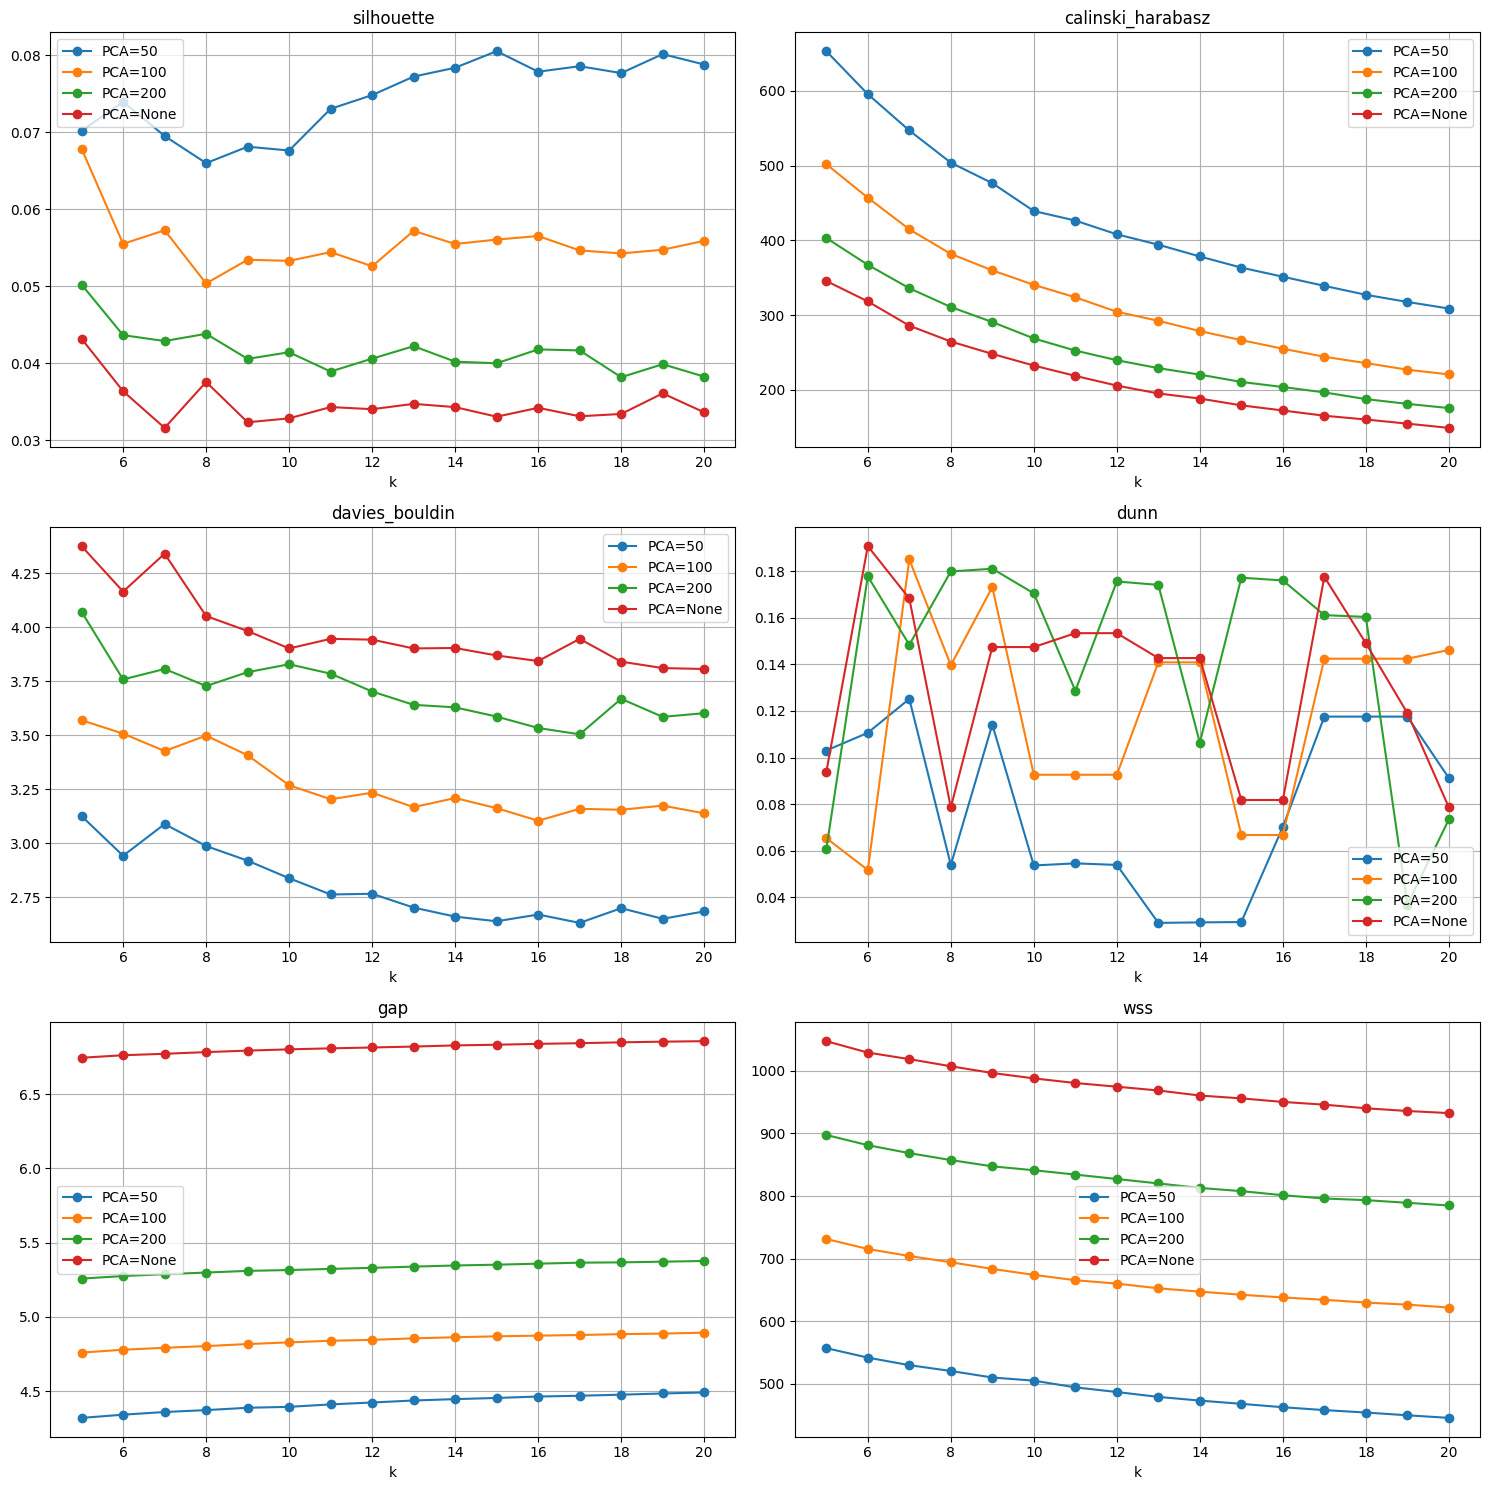

In [13]:
metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "dunn",
    "gap",
    "wss"
]

pca_candidates = [
    50,
    100,
    200,
    np.nan
]

n_cols = 2
n_rows = 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(15, 5 * n_rows) 
)

axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    
    for pca_dim in pca_candidates:
        if pd.isna(pca_dim):
            subset = df_e5_metrics[
                df_e5_metrics["pca_dim"].isna()
            ]
            label = "PCA=None"
        else:
            subset = df_e5_metrics[
                df_e5_metrics["pca_dim"] == pca_dim
            ]
            label = f"PCA={pca_dim}"
        
        ax.plot(
            subset["k"],
            subset[metric],
            marker="o",
            label=label
        )
    
    ax.set_title(metric)
    ax.set_xlabel("k")
    ax.grid(True)
    ax.legend()

plt.tight_layout()

os.makedirs(
    "../data/plots/e5/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/e5/kmeans/e5_kmeans_metrics.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Лучшая размерность, как и у предыдущих моделей: PCA = 50
При 50 компонентах все метрики лучше: максимальный силуэт (0.0805), минимальный Davies-Bouldin (2.63), максимальный Calinski-Harabasz (652). При увеличении размерности качество падает.

Кандидаты на дальнейший анализ: k = [12, 13, 14, 15, 13, 17]

In [4]:
FINAL_PCA_E5 = 50

pca_final = PCA(
    n_components=FINAL_PCA_E5,
    random_state=RANDOM_STATE
)

X_e5_final = pca_final.fit_transform(
    X_e5_norm
)

In [36]:
k_candidates = [12, 13, 14, 15, 16, 17]

In [37]:
cluster_sizes_report = {}

for k in k_candidates:

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(
        X_e5_final
    )

    df_temp = df.copy()

    df_temp['cluster'] = labels

    report = get_cluster_report(
        df_temp,
        'cluster'
    )

    cluster_sizes_report[k] = report

summary_data = []

for k in k_candidates:

    report = cluster_sizes_report[k]

    summary_data.append({

        'k': k,

        'min_cluster': report['min_size'],

        'max_cluster': report['max_size'],

        'max_cluster_pct':
            f"{report['max_size_pct']:.1%}"
    })

df_summary_e5 = pd.DataFrame(summary_data)

df_summary_e5

,k,min_cluster,max_cluster,max_cluster_pct
0,12,405,1120,10.7%
1,13,394,1084,10.4%
2,14,378,1093,10.4%
3,15,227,1078,10.3%
4,16,236,912,8.7%
5,17,232,907,8.7%


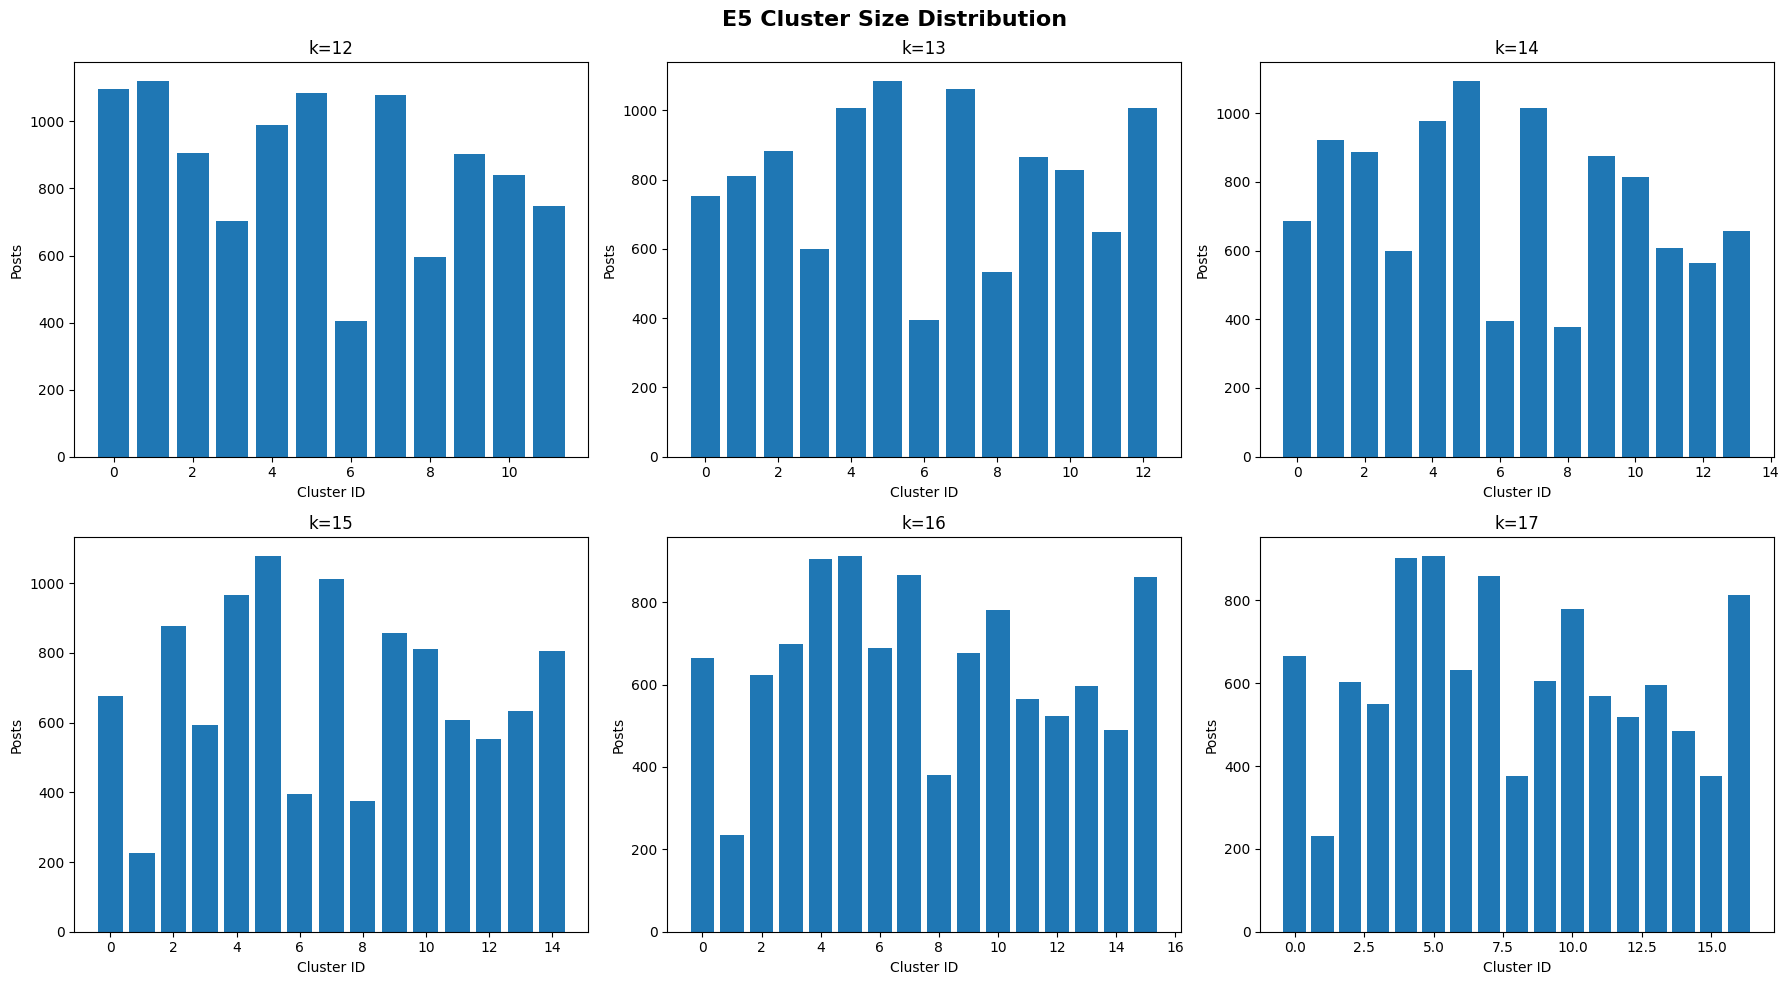

In [38]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for idx, k in enumerate(k_candidates):

    sizes = cluster_sizes_report[k]['sizes']

    axes[idx].bar(
        range(len(sizes)),
        list(sizes.values())
    )

    axes[idx].set_title(f'k={k}')

    axes[idx].set_xlabel('Cluster ID')

    axes[idx].set_ylabel('Posts')

plt.suptitle(
    'E5 Cluster Size Distribution',
    fontsize=16,
    fontweight='bold'
)

# axes[-1].axis('off')

plt.tight_layout()

os.makedirs(
    "../data/plots/e5/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/e5/kmeans/"
    "e5_cluster_sizes.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Везде распределение более менее равномерное, поэтому посмотрим на примеры кластеров

In [39]:
final_candidates_e5 = [12, 13, 14, 15, 16, 17]

In [48]:
base_examples_path = (
    "../data/results/candidate_examples/e5"
)

base_clusters_path = (
    "../data/results/final_clusters/e5"
)

os.makedirs(
    base_examples_path,
    exist_ok=True
)

os.makedirs(
    base_clusters_path,
    exist_ok=True
)

for k in final_candidates_e5:

    print("\n" + "=" * 80)
    print(f"k = {k}")
    print("=" * 80)

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(
        X_e5_final
    )

    df_cluster = df.copy()

    df_cluster['cluster'] = labels

    cluster_sizes = (
        df_cluster['cluster']
        .value_counts()
        .sort_index()
    )

    df_cluster['cluster_size'] = (
        df_cluster['cluster']
        .map(cluster_sizes)
    )

    centroid_examples = get_centroid_examples(
        X_e5_final,
        labels,
        df,
        n_examples=50
    )

    # TXT
    output_txt = (
        f"{base_examples_path}/"
        f"e5_k{k}_candidate_examples.txt"
    )

    with open(output_txt, "w", encoding="utf-8") as f:

        f.write("=" * 80 + "\n")
        f.write("E5 + KMeans\n")
        f.write(f"k = {k}\n")
        f.write(
            "TOP-50 nearest centroid examples\n"
        )
        f.write("=" * 80 + "\n\n")

        f.write("CLUSTER SIZES:\n\n")

        for cluster_id, size in cluster_sizes.items():

            f.write(
                f"Cluster {cluster_id}: "
                f"{size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        for cluster_id in sorted(cluster_sizes.index):

            f.write(f"\n{'=' * 80}\n")

            f.write(
                f"CLUSTER {cluster_id} "
                f"({cluster_sizes[cluster_id]} posts)\n"
            )

            f.write(f"{'=' * 80}\n\n")

            examples = centroid_examples.get(
                cluster_id,
                {}
            )

            texts = examples.get('texts', [])

            distances = examples.get(
                'distances',
                []
            )

            for idx, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(
                    str(text)
                    .replace('\n', ' ')
                    .split()
                )

                f.write(
                    f"[{idx+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(f"{clean_text}\n\n")

    print(f"Сохранен TXT: {output_txt}")

    # CSV
    output_csv = (
        f"{base_clusters_path}/"
        f"e5_k{k}_clusters.csv"
    )

    df_cluster[
        [
            'post_id',
            'channel_username',
            'text',
            'cluster',
            'cluster_size'
        ]
    ].to_csv(
        output_csv,
        index=False
    )

    print(f"Сохранен CSV: {output_csv}")



k = 12
Сохранен TXT: ../data/results/candidate_examples/e5/e5_k12_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/e5/e5_k12_clusters.csv

k = 13
Сохранен TXT: ../data/results/candidate_examples/e5/e5_k13_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/e5/e5_k13_clusters.csv

k = 14
Сохранен TXT: ../data/results/candidate_examples/e5/e5_k14_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/e5/e5_k14_clusters.csv

k = 15
Сохранен TXT: ../data/results/candidate_examples/e5/e5_k15_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/e5/e5_k15_clusters.csv

k = 16
Сохранен TXT: ../data/results/candidate_examples/e5/e5_k16_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/e5/e5_k16_clusters.csv

k = 17
Сохранен TXT: ../data/results/candidate_examples/e5/e5_k17_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/e5/e5_k17_clusters.csv


Результаты анализа примеров кластеров:

k=12: Кластеры слишком обобщенные, темы Telegram/TON смешиваются с законодательством, а "милые новости" и опросы находятся в одном кластере с полезным контентом.

k=13: Улучшение за счет отделения финансов и утечек данных, но тема Telegram по-прежнему раздроблена, а "милые новости" искусственно разбиты на два кластера.

k=14: Появляется небольшой "мусорный" кластер (фильмы и разрозненный контент), что сигнализирует о необходимости увеличения числа кластеров для его распада.

k=15: Хороший баланс, темы разделены чисто, но кластер транспорта еще мал, а часть разрозненного контента остается в смешанном кластере.

k=16: Оптимальная конфигурация - кластеры наиболее чистые и сбалансированные, исчез "мусорный" кластер, а тема ИИ распалась на науку, новости, технические обзоры и прикладные инструменты.

k=17: Начинается переобучение. Темы дробятся излишне мелко (например, фильмы и трейлеры в разные кластеры), что снижает интерпретируемость и обобщающую способность модели.

Итоговый выбор: **k=16**, так как это значение обеспечивает наилучший компромисс между чистотой кластеров и их сбалансированностью, а также полностью устраняет "мусорные" кластеры, присутствовавшие при меньших k.

In [5]:
FINAL_K_E5 = 16

Фиксируем финальную версию

In [6]:
pca_final = PCA(
    n_components=FINAL_PCA_E5,
    random_state=RANDOM_STATE
)

X_e5_final = pca_final.fit_transform(
    X_e5_norm
)

# KMeans
km_final = KMeans(
    n_clusters=FINAL_K_E5,
    random_state=RANDOM_STATE,
    n_init='auto'
)

labels_final = km_final.fit_predict(
    X_e5_final
)

df_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_cluster_final['cluster_e5'] = labels_final

cluster_sizes = (
    df_cluster_final['cluster_e5']
    .value_counts()
    .sort_index()
)

df_cluster_final['cluster_e5_size'] = (
    df_cluster_final['cluster_e5']
    .map(cluster_sizes)
)

Добавим названия кластеров

In [24]:
cluster_names_e5 = {
    0: "Регулирование: законы, блокировки, VPN",
    1: "Кино и YouTube: сериалы, аниме",
    2: "Наука и ИИ: конференции и исследования",
    3: "Университет: мероприятия и студенческая жизнь СПбГУ",
    4: "Apple: новости смартфонов и гаджетов",
    5: "Новости: утренние дайджесты ИИ",
    6: "Интерактив: опросы и странные новости",
    7: "Тренды ИИ: обзоры LLM и AI-агентов",
    8: "Игры: новости видеоигр",
    9: "Наука и ИИ: разработки и материалы Сколтеха",
    10: "ИИ-инструменты: нейросети для кода, дизайна, контента",
    11: "Telegram: бизнес, монетизация, TON",
    12: "Кибербезопасность: утечки данных и кибератаки",
    13: "Финансы: криптовалюты и банки",
    14: "Авто: новинки автопрома и транспорта",
    15: "IT-образование: курсы, стажировки, школы",
}

In [25]:
df_cluster_final['cluster_e5_name'] = (
    df_cluster_final['cluster_e5']
    .map(cluster_names_e5)
)

Посмотрим на распределение кластеров

In [26]:
distribution = (
    df_cluster_final[
        [
            'cluster_e5',
            'cluster_e5_name',
            'cluster_e5_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_e5')
)

distribution

,cluster_e5,cluster_e5_name,cluster_e5_size
116,0,"Регулирование: законы, блокировки, VPN",664
294,1,"Кино и YouTube: сериалы, аниме",236
0,2,Наука и ИИ: конференции и исследования,624
31,3,Университет: мероприятия и студенческая жизнь ...,699
762,4,Apple: новости смартфонов и гаджетов,905
4,5,Новости: утренние дайджесты ИИ,912
33,6,Интерактив: опросы и странные новости,688
140,7,Тренды ИИ: обзоры LLM и AI-агентов,865
777,8,Игры: новости видеоигр,381
14,9,Наука и ИИ: разработки и материалы Сколтеха,677


Сохраняем

In [27]:
os.makedirs(
    "../data/results/final_examples/e5",
    exist_ok=True
)

centroid_examples = get_centroid_examples(
    X_e5_final,
    labels_final,
    df,
    n_examples=50
)

output_path = (
    "../data/results/final_examples/"
    "e5/e5_final_examples.txt"
)

with open(output_path, "w", encoding="utf-8") as f:

    f.write("=" * 80 + "\n")
    f.write("E5 + KMeans FINAL CLUSTERIZATION\n")
    f.write(f"PCA = {FINAL_PCA_E5}\n")
    f.write(f"k = {FINAL_K_E5}\n")
    f.write("=" * 80 + "\n\n")

    f.write("CLUSTER SIZES:\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        size = cluster_sizes[cluster_id]

        name = cluster_names_e5.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(
            f"Cluster {cluster_id} "
            f"({name}): {size} posts\n"
        )

    f.write("\n" + "=" * 80 + "\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        name = cluster_names_e5.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(f"\n{'=' * 80}\n")

        f.write(
            f"CLUSTER {cluster_id}: "
            f"{name}\n"
        )

        f.write(
            f"Posts: {cluster_sizes[cluster_id]}\n"
        )

        f.write(f"{'=' * 80}\n\n")

        texts = centroid_examples[
            cluster_id
        ]['texts']

        distances = centroid_examples[
            cluster_id
        ]['distances']

        for idx, (text, dist) in enumerate(
            zip(texts, distances)
        ):

            clean_text = ' '.join(
                str(text)
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[{idx+1}] "
                f"(distance: {dist:.4f})\n"
            )

            f.write(f"{clean_text}\n\n")


    f.write("\n" + "=" * 80 + "\n")
    f.write("RANDOM EXAMPLES\n")
    f.write("=" * 80 + "\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        name = cluster_names_e5.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(f"\n{'=' * 80}\n")

        f.write(
            f"CLUSTER {cluster_id}: "
            f"{name}\n"
        )

        f.write(f"{'=' * 80}\n\n")

        cluster_texts = df_cluster_final[
            df_cluster_final['cluster_e5']
            == cluster_id
        ]['text'].tolist()

        random_indices = np.random.choice(
            len(cluster_texts),
            size=min(20, len(cluster_texts)),
            replace=False
        )

        for idx, text_idx in enumerate(
            random_indices
        ):

            clean_text = ' '.join(
                str(cluster_texts[text_idx])
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[RANDOM {idx+1}]\n"
            )

            f.write(f"{clean_text}\n\n")

In [28]:
os.makedirs(
    "../data/results/final_clusters/e5",
    exist_ok=True
)

output_csv = (
    "../data/results/final_clusters/"
    "e5/e5_final_clusters.csv"
)

df_cluster_final.to_csv(
    output_csv,
    index=False
)

Визуализация

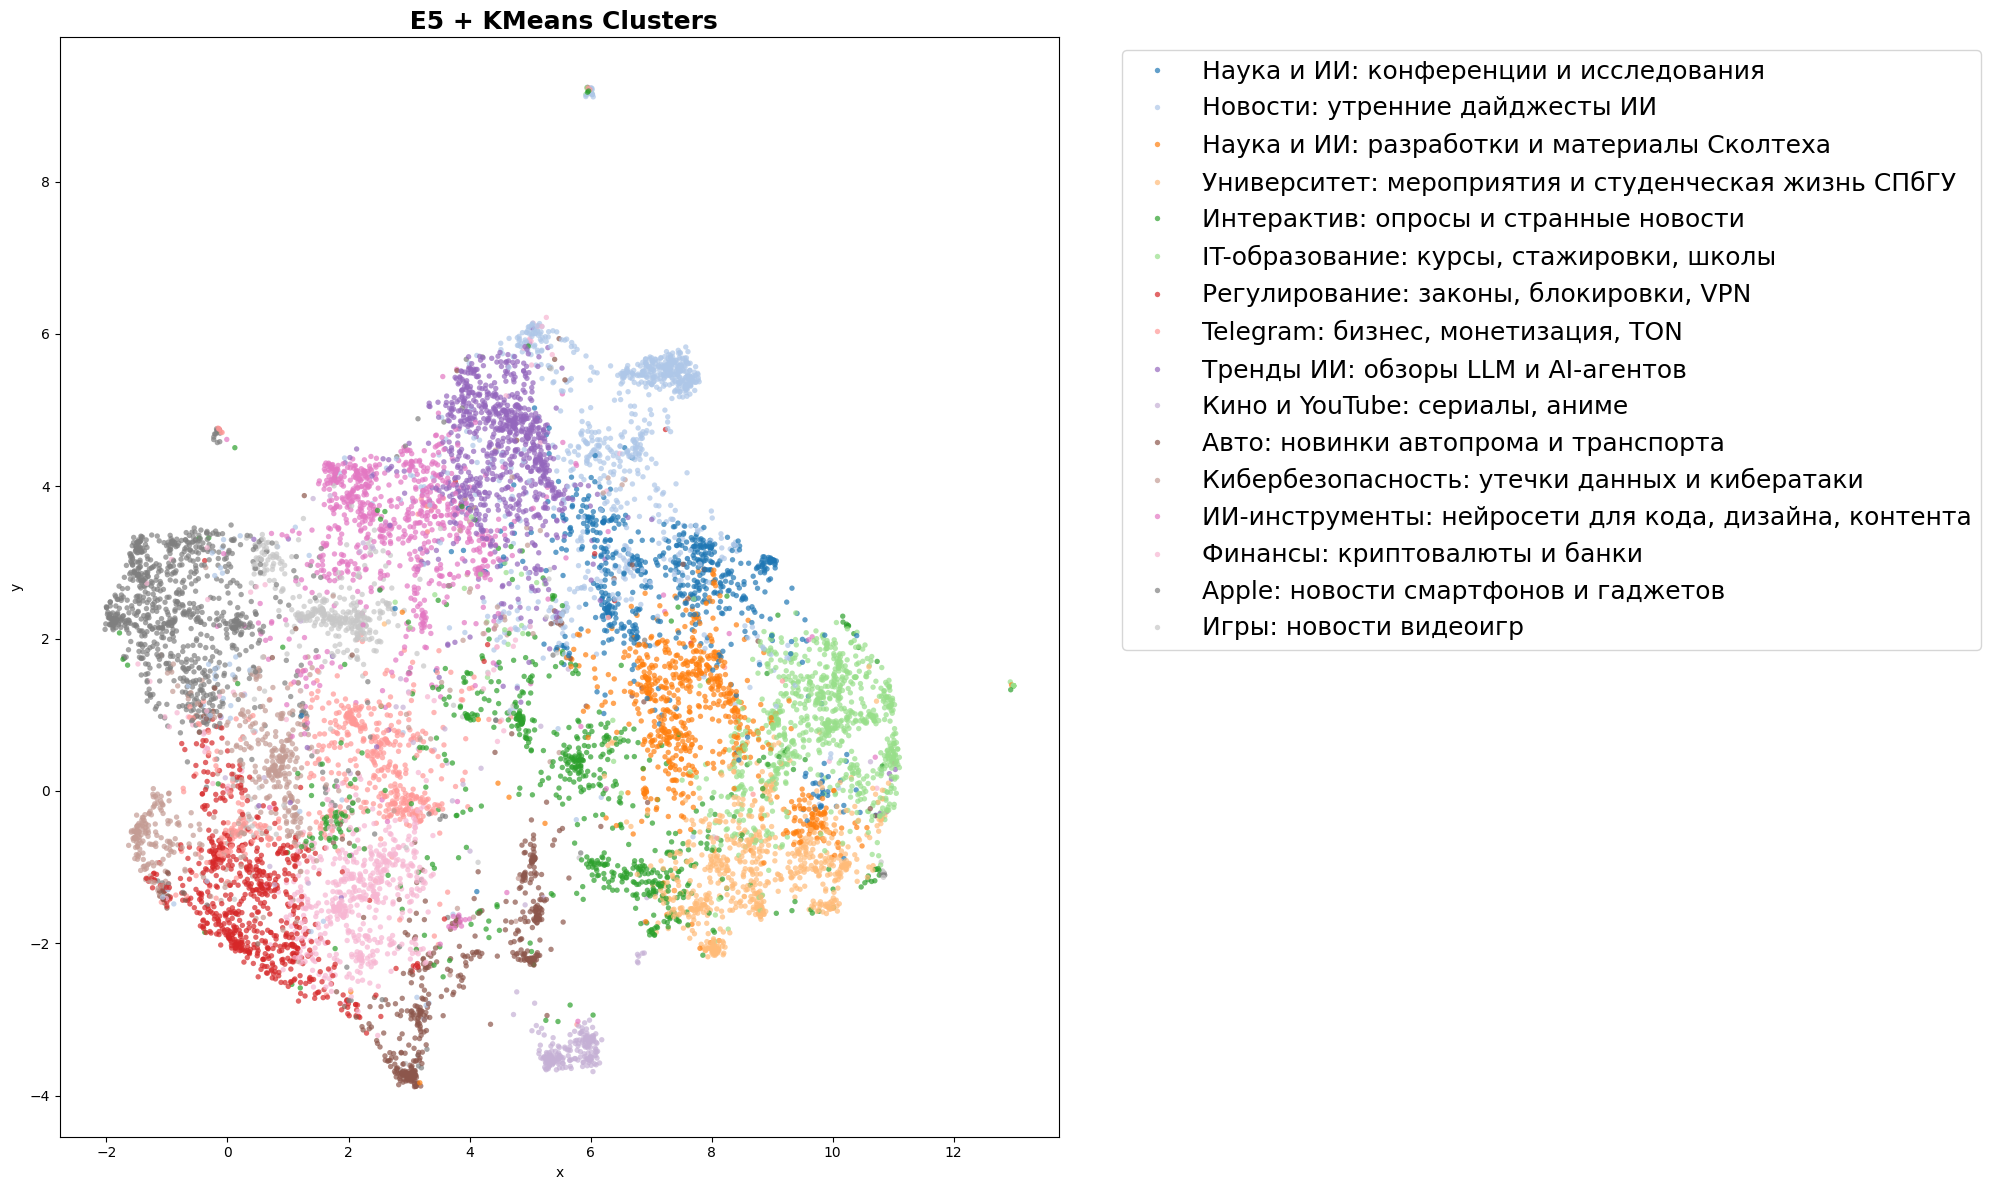

In [35]:
import umap.umap_ as umap

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.2,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = umap_reducer.fit_transform(
    X_e5_final
)

plot_df = pd.DataFrame({
    'x': X_umap[:, 0],
    'y': X_umap[:, 1],
    'cluster_name':
        df_cluster_final[
            'cluster_e5_name'
        ]
})

plt.figure(figsize=(20, 12))

sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='cluster_name',
    palette='tab20',
    s=15,
    alpha=0.7,
    linewidth=0

)

plt.title(
    ' E5 + KMeans Clusters',
    fontsize=18,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=18
)

plt.tight_layout()

os.makedirs(
    "../data/plots/e5/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/e5/kmeans/"
    "e5_kmeans_final_umap.png",
    dpi=200,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

# HDBSCAN для E5

In [ ]:
min_cluster_sizes = [100, 150, 200]
min_samples_list = [1, 3, 5]

umap_n_neighbors = [50, 100, 150]
umap_n_components = [10, 15, 20]

In [17]:
from hdbscan.validity import validity_index
import warnings
import hdbscan
from umap import UMAP

warnings.filterwarnings("ignore")

results_hdbscan = []

for nn in umap_n_neighbors:

    for nc in umap_n_components:

        print("=" * 80)
        print(f"UMAP neighbors={nn}, components={nc}")

        umap_model = UMAP(
            n_neighbors=nn,
            n_components=nc,
            min_dist=0.1,
            metric='cosine',
            random_state=42
        )

        X_umap = umap_model.fit_transform(
            X_e5_norm
        )

        X_umap = X_umap.astype(np.float64)

        for mcs in min_cluster_sizes:
            for ms in min_samples_list:
                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=mcs,
                    min_samples=ms,
                    metric='euclidean',
                    cluster_selection_method='eom',
                    prediction_data=True,
                    core_dist_n_jobs=-1
                )

                labels = clusterer.fit_predict(
                    X_umap
                )

                n_clusters = len(
                    set(labels)
                ) - (1 if -1 in labels else 0)

                noise_ratio = np.mean(
                    labels == -1
                )

                sil = np.nan
                dbcv = np.nan

                valid_mask = labels != -1

                unique_valid = np.unique(
                    labels[valid_mask]
                )

                if len(unique_valid) >= 2:
                    try:
                        sil = silhouette_score(
                            X_umap[valid_mask],
                            labels[valid_mask],
                            metric='euclidean'
                        )
                    except:
                        pass
                try:
                    dbcv = validity_index(
                        X_umap,
                        labels
                    )
                except:
                    pass

                results_hdbscan.append({
                    'umap_neighbors': nn,
                    'umap_components': nc,
                    'min_cluster_size': mcs,
                    'min_samples': ms,
                    'n_clusters': n_clusters,
                    'noise_ratio': noise_ratio,
                    'silhouette': sil,
                    'dbcv': dbcv
                })

UMAP neighbors=50, components=10


SystemError: CPUDispatcher(<function nn_descent at 0x000001A028B76520>) returned a result with an exception set

In [ ]:
df_hdbscan = pd.DataFrame(
    results_hdbscan
)

os.makedirs(
    "../data/results/metrics/e5",
    exist_ok=True
)

df_hdbscan.to_csv(
    "../data/results/metrics/e5/"
    "e5_hdbscan_metrics.csv",
    index=False
)

df_hdbscan.head()

,umap_neighbors,umap_components,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,50,10,100,1,21,0.377185,0.406267,-0.040002
1,50,10,100,3,11,0.199962,0.230303,-0.203581
2,50,10,100,5,19,0.403076,0.433260,0.053391
3,50,10,150,1,8,0.184676,0.239064,-0.247689
4,50,10,150,3,7,0.176842,0.201931,-0.188245


In [18]:
df_hdbscan = pd.read_csv("../data/results/metrics/e5/"
    "e5_hdbscan_metrics.csv")

In [23]:
df_hdbscan_filtered = df_hdbscan[

    (df_hdbscan['n_clusters'] >= 5) &
    (df_hdbscan['n_clusters'] <= 20) &
    (df_hdbscan['noise_ratio'] <= 0.35) & 
    (df_hdbscan['dbcv'] >= 0.1) &
    (df_hdbscan['silhouette'] >= 0.20)

].sort_values(
    ['dbcv', 'silhouette'],
    ascending=False
)

df_hdbscan_filtered.reset_index(drop=True)

,umap_neighbors,umap_components,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,100,20,200,5,5,0.246489,0.321180,0.221626
1,100,20,150,5,8,0.199293,0.230254,0.184126
2,100,15,200,1,7,0.310882,0.342968,0.148960
3,50,20,100,3,11,0.179039,0.244958,0.111387


Рассмотрим эти конфигурации

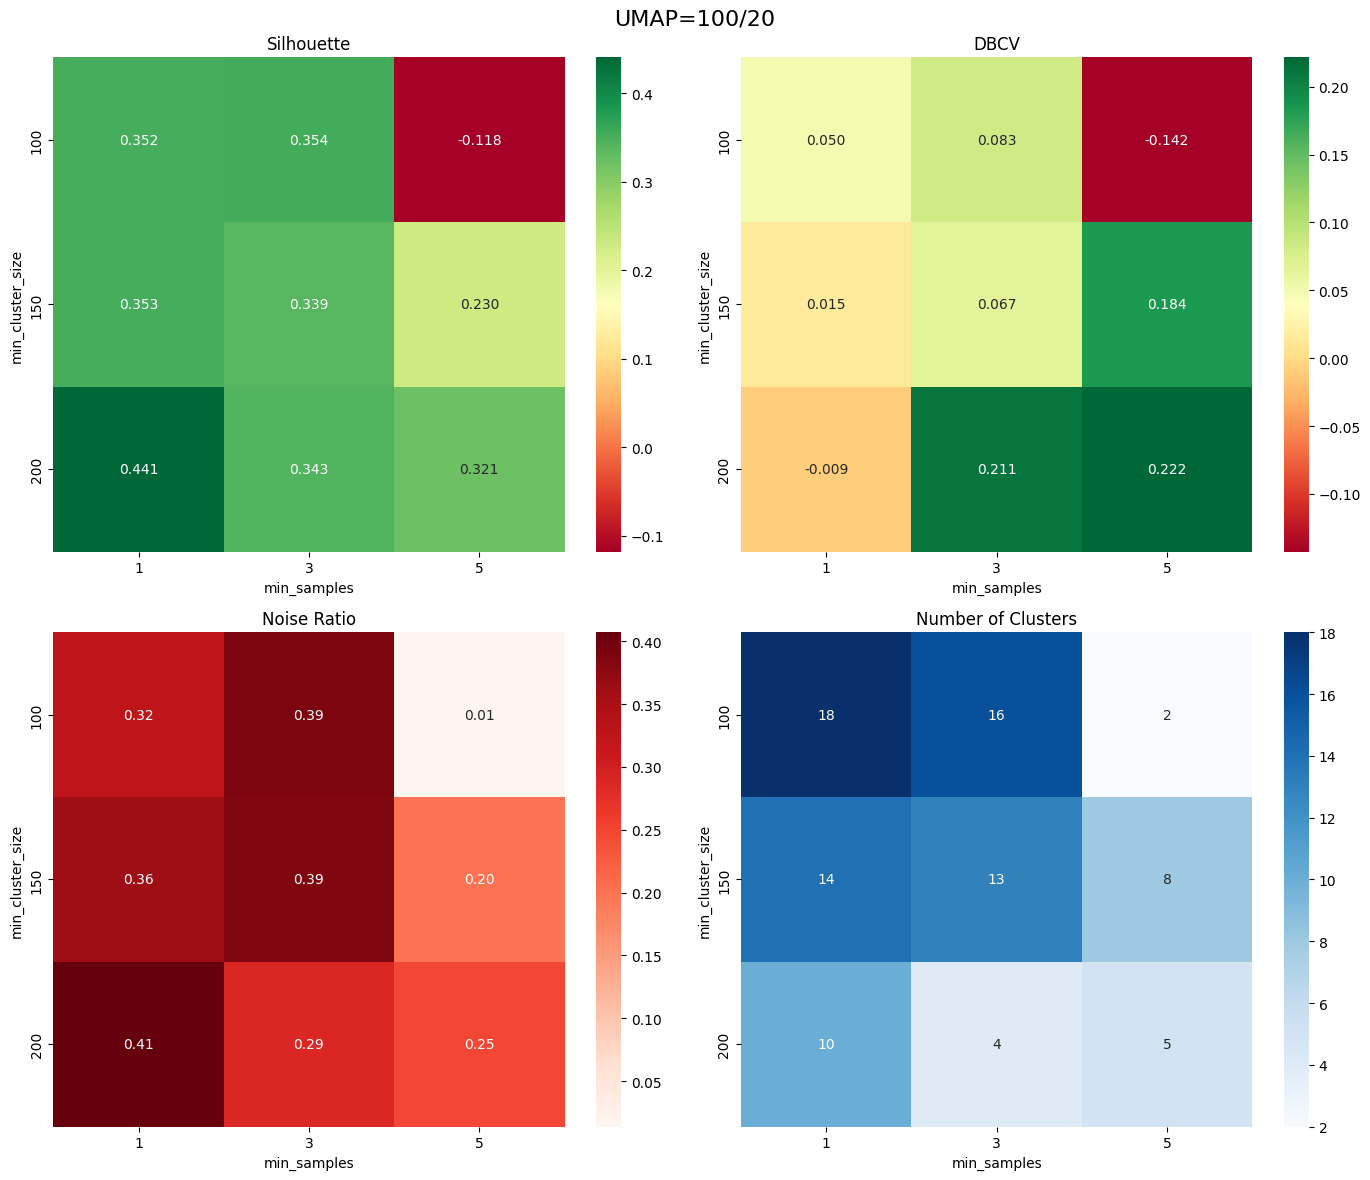

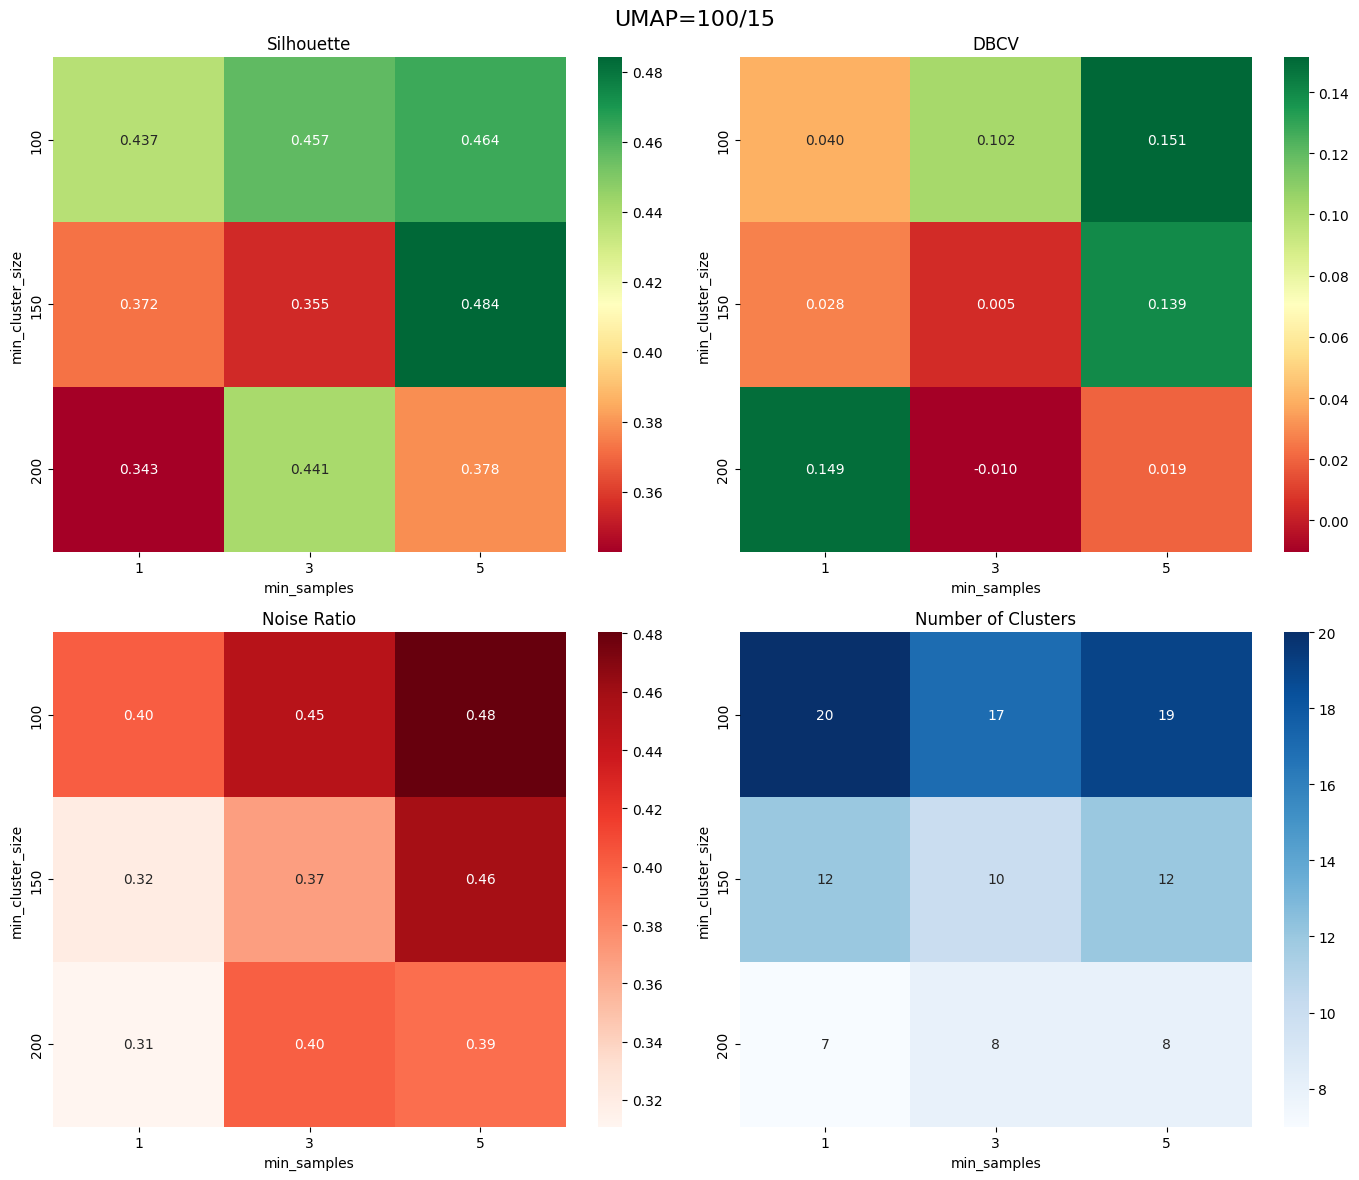

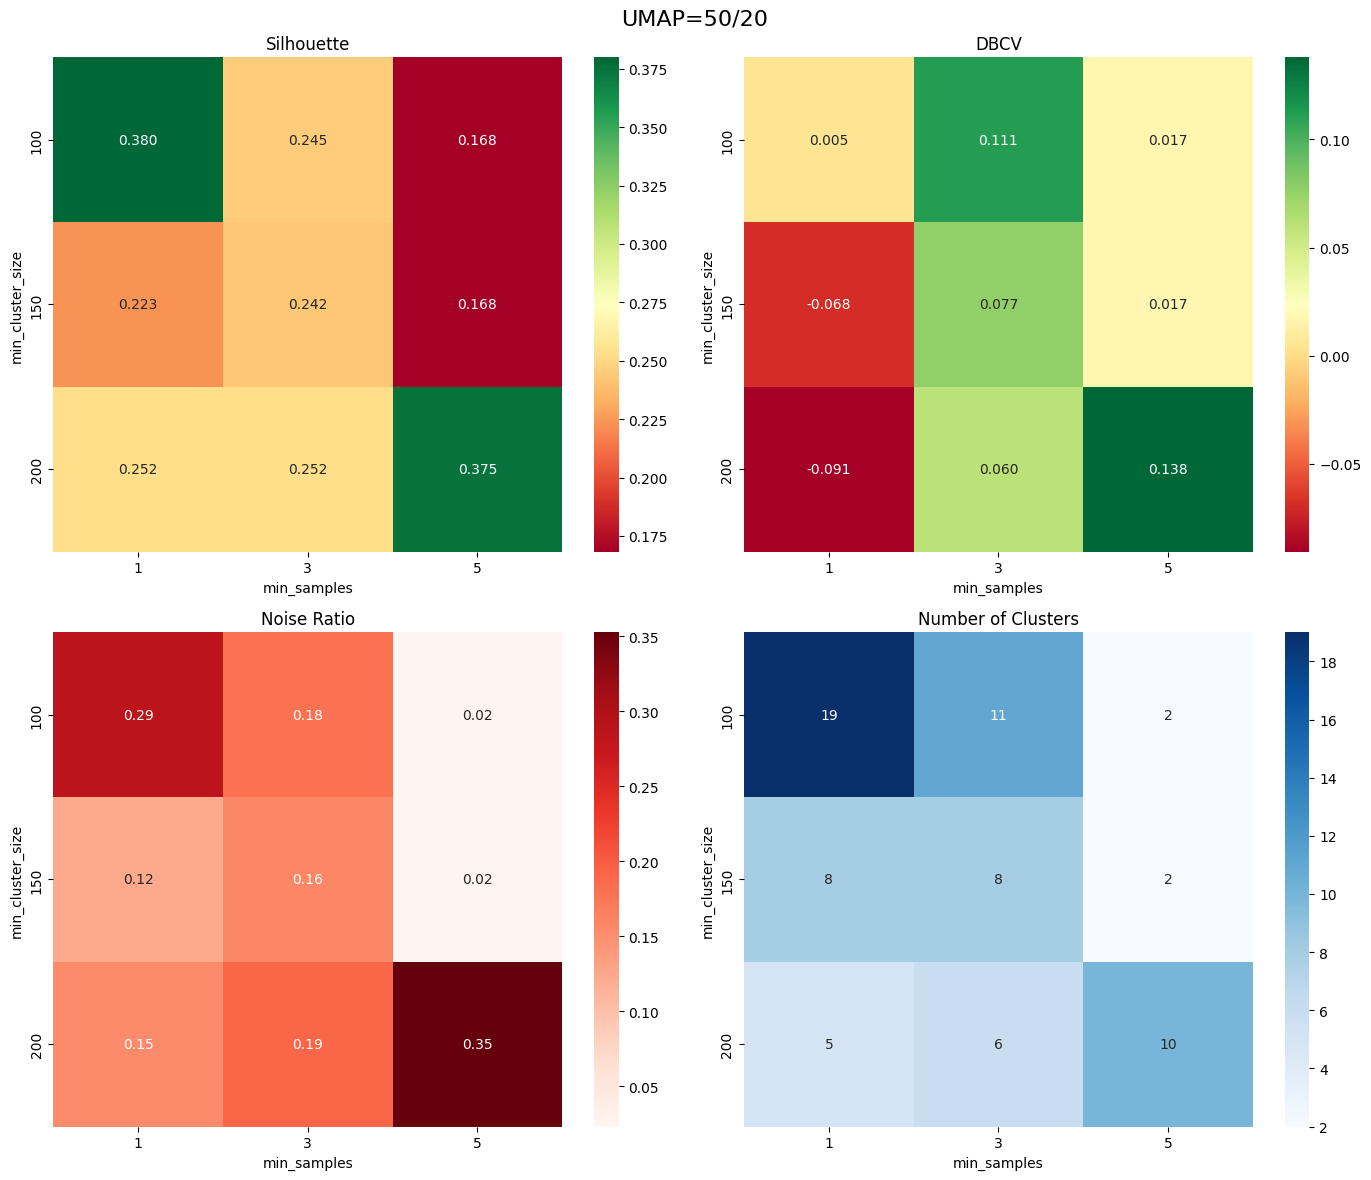

In [ ]:
top_configs = df_hdbscan_filtered[
    [
        'umap_neighbors',
        'umap_components'
    ]
].drop_duplicates()

for _, row in top_configs.iterrows():

    nn = row['umap_neighbors']
    nc = row['umap_components']

    subset = df_hdbscan[

        (df_hdbscan['umap_neighbors'] == nn) &
        (df_hdbscan['umap_components'] == nc)

    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 12)
    )


    # SILHOUETTE
    pivot_sil = subset.pivot_table(
        values='silhouette',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_sil,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[0, 0]
    )

    axes[0, 0].set_title(
        'Silhouette'
    )

    # DBCV
    pivot_dbcv = subset.pivot_table(
        values='dbcv',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_dbcv,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[0, 1]
    )

    axes[0, 1].set_title(
        'DBCV'
    )

    # NOISE
    pivot_noise = subset.pivot_table(
        values='noise_ratio',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_noise,
        annot=True,
        fmt='.2f',
        cmap='Reds',
        ax=axes[1, 0]
    )

    axes[1, 0].set_title(
        'Noise Ratio'
    )

    # N CLUSTERS
    pivot_clusters = subset.pivot_table(
        values='n_clusters',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_clusters,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        ax=axes[1, 1]
    )

    axes[1, 1].set_title(
        'Number of Clusters'
    )

    plt.suptitle(
        f'UMAP={nn}/{nc}',
        fontsize=16
    )

    plt.tight_layout()

    os.makedirs(
        "../data/plots/e5/hdbscan",
        exist_ok=True
    )

    plt.savefig(
        f"../data/plots/e5/hdbscan/"
        f"heatmap_umap_{nn}_{nc}.png",
        dpi=200,
        bbox_inches='tight'
    )

    plt.show()

Посмотрим на примеры кластеров для этих конфигураций

In [96]:
candidate_configs = [

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 200,
        "min_samples": 5
    },

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 150,
        "min_samples": 5
    },

    {
        "umap_neighbors": 100,
        "umap_components": 15,
        "min_cluster_size": 200,
        "min_samples": 1
    },

    {
        "umap_neighbors": 50,
        "umap_components": 20,
        "min_cluster_size": 100,
        "min_samples": 3
    }
]

In [ ]:
os.makedirs(
    "../data/results/candidate_examples/e5_hdbscan",
    exist_ok=True
)

for cfg in candidate_configs:

    nn = cfg['umap_neighbors']
    nc = cfg['umap_components']

    mcs = cfg['min_cluster_size']
    ms = cfg['min_samples']

    print("=" * 80)

    print(
        f"UMAP={nn}/{nc} | "
        f"MCS={mcs} | "
        f"MS={ms}"
    )

    
    umap_model = UMAP(
        n_neighbors=nn,
        n_components=nc,
        min_dist=0.1,
        metric='cosine',
        random_state=RANDOM_STATE
    )

    X_umap = umap_model.fit_transform(
        X_e5_norm
    )

    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True,
        core_dist_n_jobs=-1
    )

    labels = clusterer.fit_predict(
        X_umap
    )
    
    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(cluster_sizes)

    non_noise_mask = labels != -1
    centroid_examples = get_centroid_examples(
        X_umap[non_noise_mask],
        labels[non_noise_mask],
        df[non_noise_mask].reset_index(drop=True),
        n_examples=50
    )

    output_path = (
        "../data/results/candidate_examples/"
        "e5_hdbscan/"
        f"e5_hdbscan_"
        f"umap{nn}_{nc}_"
        f"mcs{mcs}_"
        f"ms{ms}.txt"
    )

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("=" * 80 + "\n")
        f.write("E5 + UMAP + HDBSCAN\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"UMAP neighbors: {nn}\n")
        f.write(f"UMAP components: {nc}\n")
        f.write(f"min_cluster_size: {mcs}\n")
        f.write(f"min_samples: {ms}\n\n")


        # CLUSTER SIZES
        f.write("CLUSTER SIZES:\n\n")

        for cid, size in cluster_sizes.items():

            f.write(
                f"Cluster {cid}: "
                f"{size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        # EXAMPLES
        for cid in sorted(
            centroid_examples.keys()
        ):

            f.write(f"\n{'='*80}\n")

            f.write(
                f"CLUSTER {cid}\n"
            )

            f.write(f"{'='*80}\n\n")

            texts = centroid_examples[
                cid
            ]['texts']

            distances = centroid_examples[
                cid
            ]['distances']

            for i, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(

                    str(text)

                    .replace('\n', ' ')

                    .split()
                )

                f.write(
                    f"[{i+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(
                    f"{clean_text}\n\n"
                )

UMAP=100/20 | MCS=200 | MS=5
-1    2580
 0     207
 1    5345
 2    1465
 3     612
 4     258
Name: count, dtype: int64
UMAP=100/20 | MCS=150 | MS=5
-1    2086
 0     207
 1    5345
 2     187
 3     151
 4    1465
 5     156
 6     612
 7     258
Name: count, dtype: int64
UMAP=100/15 | MCS=200 | MS=1
-1    3254
 0     239
 1    2916
 2    1613
 3     456
 4     659
 5     758
 6     572
Name: count, dtype: int64
UMAP=50/20 | MCS=100 | MS=3
-1     1874
 0      190
 1     6004
 2      258
 3      609
 4      101
 5      152
 6      160
 7      113
 8      143
 9      102
 10     761
Name: count, dtype: int64


Конфигурация 1: Слишком сильно обобщает. Весь ИИ (образование, новости, подкасты) склеился в один гигантский кластер, что делает анализ плоским и недетализированным.

Конфигурация 2 (оптимальная): Единственная сумела разделить «человеческий» ИИ (EdTech, карьера) и «технический» ИИ (новости моделей), плюс дала чистые кластеры по безопасности и играм без лишней фрагментации.

Конфигурация 3: Авто и образование выделены хорошо, но тема ИИ неестественно раздроблена на три куска, а главная проблема - огромный шумовой кластер, куда попало слишком много постов.

Конфигурация 4: Чистые кластеры по кино и Apple, но многие темы разваливаются на микро-кластеры.

Итоговая конфигурация: **(100,20,150,5)** 

Зафиксируем финальную версию

In [40]:
umap_model = UMAP(
    n_neighbors=100,
    n_components=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_hdbscan_final = umap_model.fit_transform(X_e5_norm)

hdbscan_final = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    core_dist_n_jobs=-1
)

labels_hdbscan = hdbscan_final.fit_predict(X_hdbscan_final.astype(np.float64))

print("Clusters:",
      len(set(labels_hdbscan)) -
      (1 if -1 in labels_hdbscan else 0))

print("Noise ratio:",
      np.mean(labels_hdbscan == -1))

Clusters: 8
Noise ratio: 0.1992930161459826


In [42]:
df_hdbscan_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_hdbscan_cluster_final['cluster_e5_hdbscan'] = labels_hdbscan

cluster_sizes = (
    df_hdbscan_cluster_final['cluster_e5_hdbscan']
    .value_counts()
    .sort_index()
)

df_hdbscan_cluster_final['cluster_e5_hdbscan_size'] = (
    df_hdbscan_cluster_final['cluster_e5_hdbscan']
    .map(cluster_sizes)
)

Добавим названия кластеров

In [43]:
cluster_names_e5_hdbscan = {
   -1: "Прочее / Шум",
    0: "Авто: электрокары, такси, каршеринг",
    1: "IT-образование: подкасты, карьера",
    2: "Финансы: курсы, трейдинг, биткоин",
    3: "Кибербезопасность: утечки, вирусы, хакеры",
    4: "Тренды ИИ: GPT, Gemini, Claude",
    5: "Кино и YouTube: новинки, аниме, трейлеры",
    6: "Игры: железо (RTX), консоли (PS, Switch)",
    7: "Регулирование: YouTube, TikTok, мессенджеры"
}

In [44]:
df_hdbscan_cluster_final['cluster_e5_hdbscan_name'] = (
    df_hdbscan_cluster_final['cluster_e5_hdbscan']
    .map(cluster_names_e5_hdbscan)
)

Посмотрим на распределение кластеров

In [45]:
distribution = (
    df_hdbscan_cluster_final[
        [
            'cluster_e5_hdbscan',
            'cluster_e5_hdbscan_name',
            'cluster_e5_hdbscan_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_e5_hdbscan')
)

distribution

,cluster_e5_hdbscan,cluster_e5_hdbscan_name,cluster_e5_hdbscan_size
1,-1,Прочее / Шум,2086
771,0,"Авто: электрокары, такси, каршеринг",207
0,1,"IT-образование: подкасты, карьера",5345
294,2,"Финансы: курсы, трейдинг, биткоин",187
439,3,"Кибербезопасность: утечки, вирусы, хакеры",151
568,4,"Тренды ИИ: GPT, Gemini, Claude",1465
786,5,"Кино и YouTube: новинки, аниме, трейлеры",156
774,6,"Игры: железо (RTX), консоли (PS, Switch)",612
841,7,"Регулирование: YouTube, TikTok, мессенджеры",258


Сохранение

In [46]:
os.makedirs(
    "../data/results/final_clusters/e5_hdbscan",
    exist_ok=True
)

output_csv = (
    "../data/results/final_clusters/"
    "e5_hdbscan/e5_hdbscan_final_clusters.csv"
)

df_hdbscan_cluster_final.to_csv(
    output_csv,
    index=False
)

Визуализация

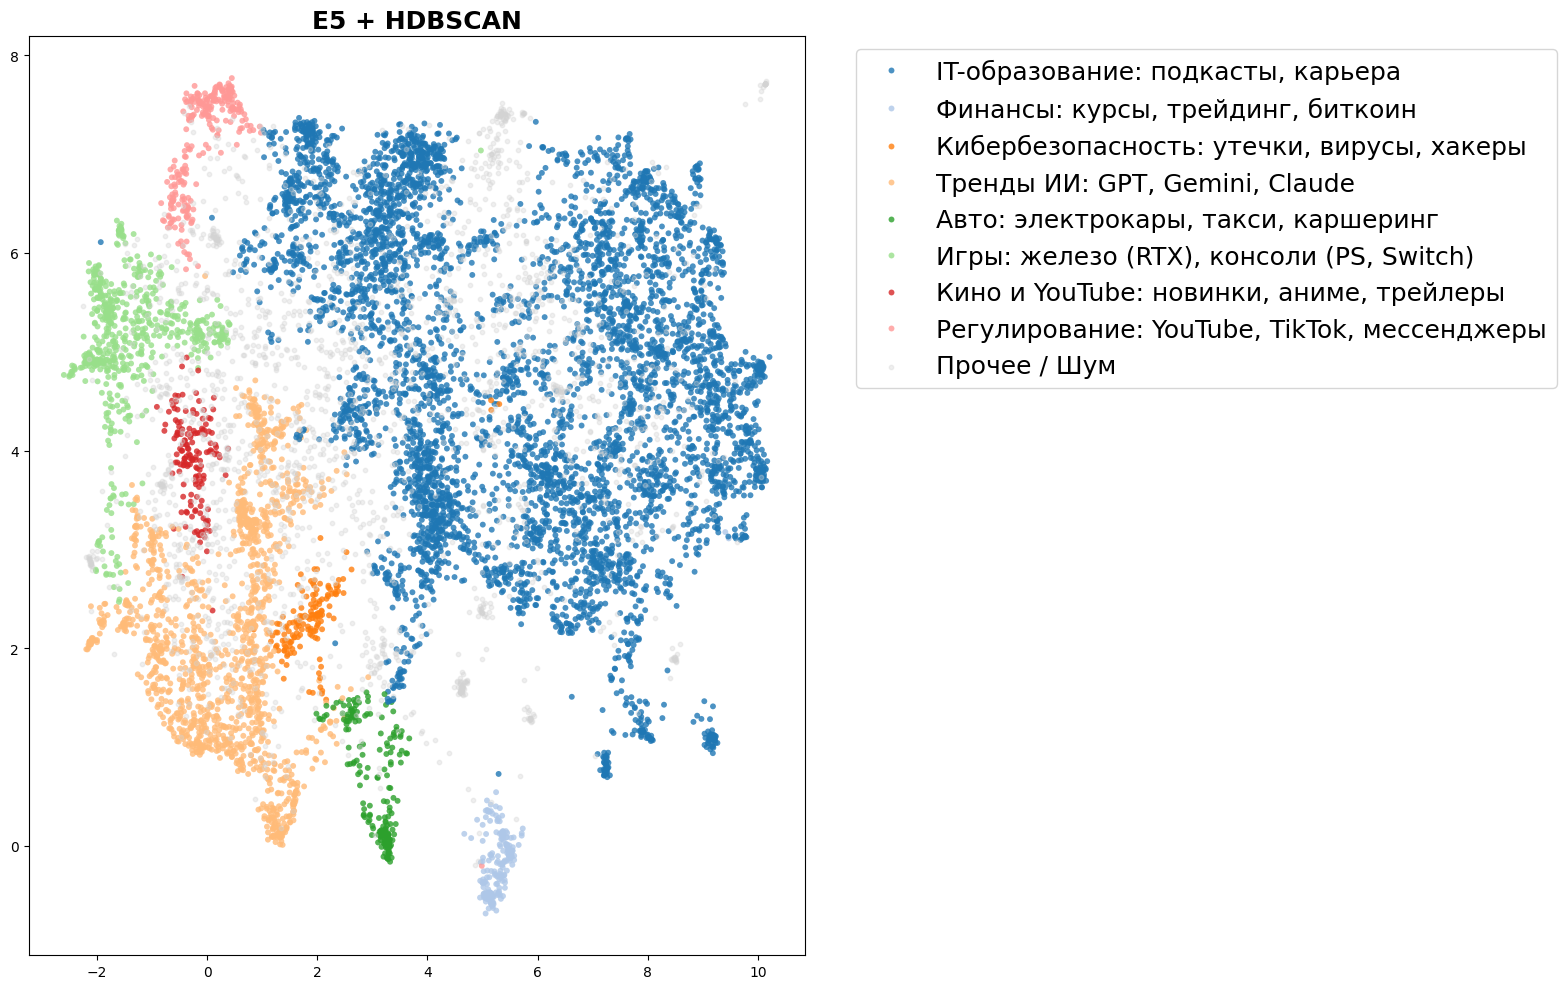

In [49]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.2,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = umap_reducer.fit_transform(
    X_e5_norm
)

plt.figure(figsize=(16, 10))

mask_clusters = labels_hdbscan != -1

hue_names = pd.Series(labels_hdbscan).map(cluster_names_e5_hdbscan)

sns.scatterplot(
    x=X_umap[mask_clusters, 0],
    y=X_umap[mask_clusters, 1],
    hue=hue_names[mask_clusters],
    palette='tab20',
    s=18,
    alpha=0.8,
    linewidth=0
)

mask_noise = labels_hdbscan == -1
plt.scatter(
    X_umap[mask_noise, 0],
    X_umap[mask_noise, 1],
    c='lightgray',
    s=10,
    alpha=0.35,
    label='Прочее / Шум'
)

plt.title(
    'E5 + HDBSCAN',
    fontsize=18,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=18
)

plt.tight_layout()

os.makedirs(
    "../data/plots/e5/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/e5/hdbscan/"
    "e5_hdbscan_umap.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Обработка шума

Центроиды имеющихся кластеров

In [106]:
valid_mask = labels_hdbscan != -1

X_core = X_hdbscan_final[valid_mask]
labels_core = labels_hdbscan[valid_mask]

centroids = {}

for c in np.unique(labels_core):

    centroids[c] = X_core[labels_core == c].mean(axis=0)

Присваиваем шум к ближайшим центроидам

In [107]:
from sklearn.metrics.pairwise import cosine_distances

X_noise = X_hdbscan_final[labels_hdbscan == -1]

noise_indices = np.where(labels_hdbscan == -1)[0]

assigned_clusters = []

for i in range(len(X_noise)):

    dists = []

    for c in centroids:

        dist = cosine_distances(
            X_noise[i].reshape(1, -1),
            centroids[c].reshape(1, -1)
        )[0][0]

        dists.append((c, dist))

    best_cluster = min(dists, key=lambda x: x[1])[0]
    assigned_clusters.append(best_cluster)

assigned_clusters = np.array(assigned_clusters)

Добавляем колонку в датафрейм

In [108]:
labels_hdbscan_final = labels_hdbscan.copy()

labels_hdbscan_final[labels_hdbscan_final == -1] = assigned_clusters


df_hdbscan_cluster_final['cluster_e5_hdbscan_final'] = labels_hdbscan_final

In [109]:
cluster_sizes_final = (
    df_hdbscan_cluster_final['cluster_e5_hdbscan_final']
    .value_counts()
    .sort_index()
)

df_hdbscan_cluster_final['cluster_e5_hdbscan_final_size'] = (
    df_hdbscan_cluster_final['cluster_e5_hdbscan_final']
    .map(cluster_sizes_final)
)

df_hdbscan_cluster_final['cluster_e5_hdbscan_final_name'] = (
    df_hdbscan_cluster_final['cluster_e5_hdbscan_final']
    .map(cluster_names_e5_hdbscan)
)

df_hdbscan_cluster_final.head()

,post_id,channel_username,text,cluster_e5_hdbscan,cluster_e5_hdbscan_size,cluster_e5_hdbscan_name,cluster_e5_hdbscan_final,cluster_e5_hdbscan_final_size,cluster_e5_hdbscan_final_name
0,1813,AI_point_of_view,🤔 Искусственный интеллект: угроза или новые во...,1,5345,"EdTech: IT-образование, Подкасты, Карьера",1,6269,"EdTech: IT-образование, Подкасты, Карьера"
1,1809,AI_point_of_view,👩‍🎓 **Самообучение без разметки: лекция Алексе...,-1,2086,Шум,1,6269,"EdTech: IT-образование, Подкасты, Карьера"
2,1808,AI_point_of_view,📡▶️ **Искусственный интеллект: как научить маш...,1,5345,"EdTech: IT-образование, Подкасты, Карьера",1,6269,"EdTech: IT-образование, Подкасты, Карьера"
3,1805,AI_point_of_view,*️⃣**Физика + ИИ** **от Сколтеха** **Владимир ...,1,5345,"EdTech: IT-образование, Подкасты, Карьера",1,6269,"EdTech: IT-образование, Подкасты, Карьера"
4,1804,AI_point_of_view,⚡️**ЗАВТРА:** **Sber Conf: Open Source & AI Ag...,1,5345,"EdTech: IT-образование, Подкасты, Карьера",1,6269,"EdTech: IT-образование, Подкасты, Карьера"


Сохраняем

In [110]:
output_final = (
    "../data/results/final_clusters/e5_hdbscan/"
    "e5_hdbscan_final_clusters_no_noise.csv"
)

df_hdbscan_cluster_final.to_csv(output_final, index=False)

Посмотрим на итоговое распределение

In [111]:
df_hdbscan_cluster_final[
    'cluster_e5_hdbscan_final_name'
].value_counts()

cluster_e5_hdbscan_final_name
EdTech: IT-образование, Подкасты, Карьера                 6269
AI: Новости моделей (GPT, Gemini, Claude)                 1711
Гейминг: Железо (RTX), Консоли (PS, Switch)                728
Кино и Сериалы: Новинки, Аниме, Трейлеры                   639
Соцсети и Regul'ирование: YouTube, TikTok, Мессенджеры     428
Авто: Электрокары, Такси, Каршеринг                        297
Кибербезопасность: Утечки, Вирусы, Хакеры                  202
Крипта: Курсы, Трейдинг, Биткоин                           193
Name: count, dtype: int64

Визуализация

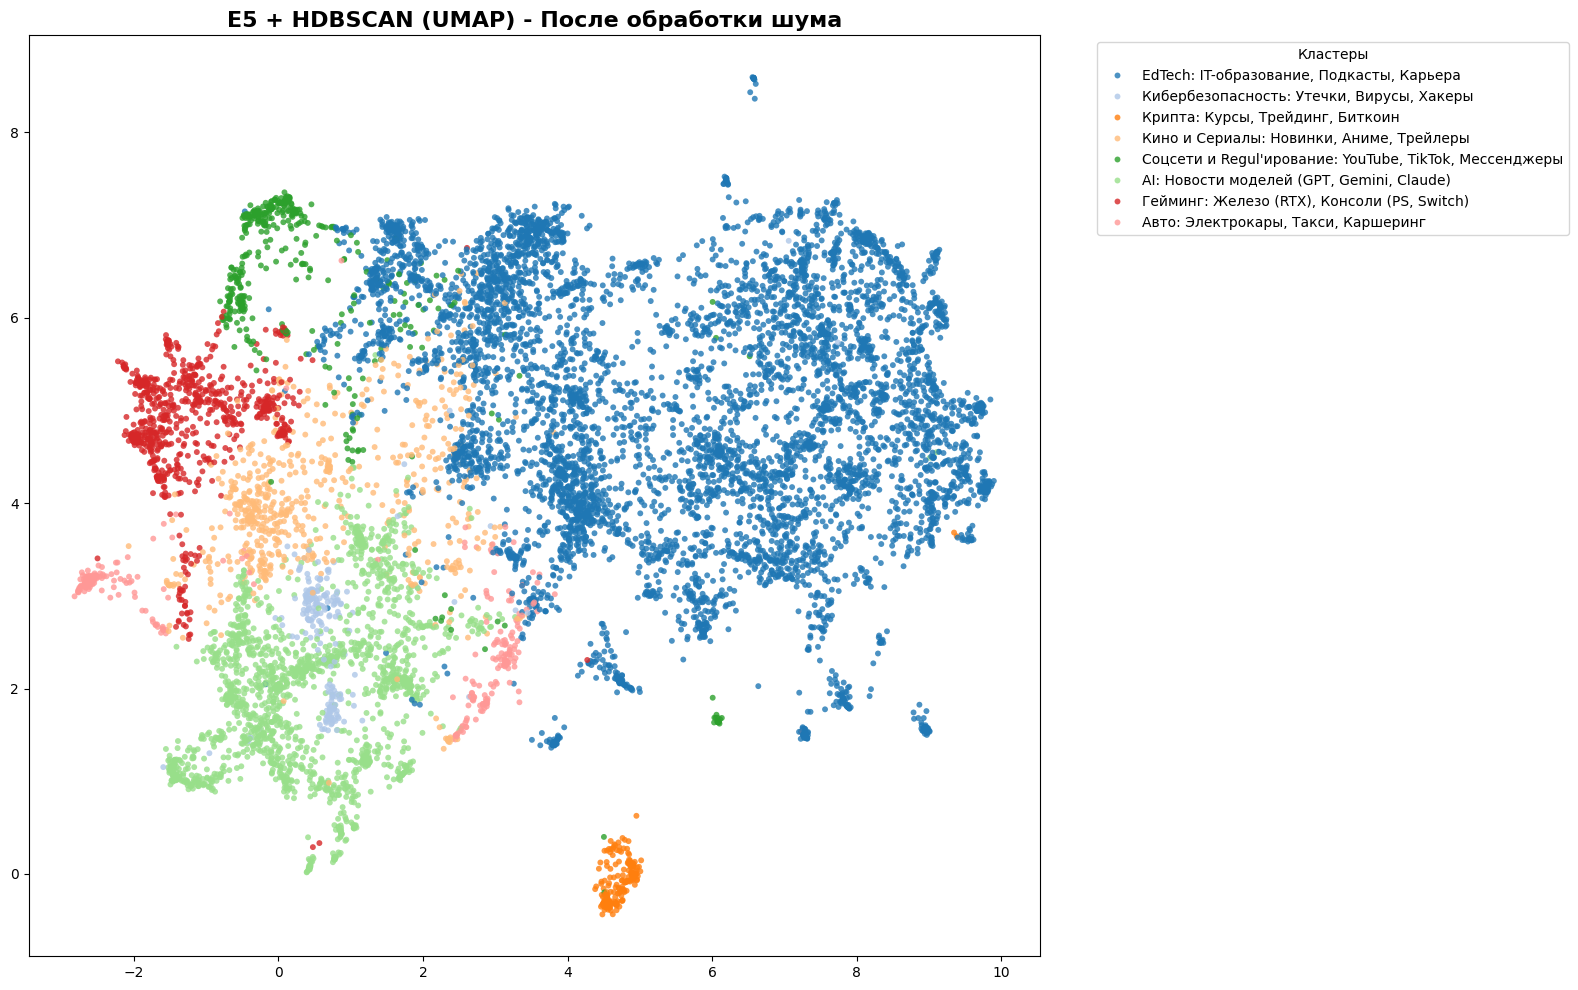

In [112]:
X_umap_final = umap_reducer.fit_transform(X_e5_norm)

plt.figure(figsize=(16, 10))

labels_final = labels_hdbscan_final

hue_names_final = pd.Series(labels_final).map(cluster_names_e5_hdbscan)

sns.scatterplot(
    x=X_umap_final[:, 0],
    y=X_umap_final[:, 1],
    hue=hue_names_final,
    palette='tab20',
    s=18,
    alpha=0.8,
    linewidth=0
)

plt.title(
    'E5 + HDBSCAN (UMAP) - После обработки шума',
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Кластеры'
)

plt.tight_layout()

os.makedirs(
    "../data/plots/e5/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/e5/hdbscan/"
    "e5_hdbscan_umap_final_no_noise.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()